# Is ICE's rookie-attrition problem happening anywhere else?

`icehires` found ICE's 2025 hiring surge came with unusually fast new-hire turnover -- more than a
quarter gone before their first year is up. Is that ICE-only, and is there a cheap way to check
hundreds of other agencies without hand-building a cohort analysis for each one?

This notebook is as much about the method as the answer: the obvious first attempt breaks twice
before it works. Both breakages and the fixes are shown below, not just described.

In [1]:
import sys; sys.path.insert(0, "src")
import lib
import pandas as pd, matplotlib.pyplot as plt, matplotlib.ticker as mtick, matplotlib.dates as mdates
from IPython.display import display, Markdown
pd.set_option("display.max_columns", 30)

def show(df, pct=(), index=False, na_rep="—"):
    fmt = {}
    for c in df.columns:
        col = df[c]
        if c in pct:
            fmt[c] = lambda v: "" if pd.isna(v) else f"{v:,.1f}%"
        elif pd.api.types.is_numeric_dtype(col):
            s = col.dropna()
            whole = len(s) > 0 and bool((s == s.round()).all())
            fmt[c] = (lambda v: "" if pd.isna(v) else f"{int(round(v)):,}") if whole \
                     else (lambda v: "" if pd.isna(v) else f"{v:,.1f}")
    sty = df.style.format(fmt, na_rep=na_rep)
    return sty if index else sty.hide(axis="index")

def ym_label(ym):
    return pd.to_datetime(str(ym), format="%Y%m").strftime("%b %Y")

C_MAIN, C_ALT, C_MUTED = "#2166ac", "#c0392b", "#8a8f98"
plt.rcParams.update({
    "figure.dpi": 120, "savefig.bbox": "tight", "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": "#bbbbbb",
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlepad": 10,
    "axes.labelcolor": "#444", "axes.labelsize": 10, "xtick.color": "#444", "ytick.color": "#444",
    "axes.grid": True, "axes.axisbelow": True, "grid.color": "#dddddd", "grid.linewidth": 0.7,
    "legend.frameon": False,
})
def date_x(ax):
    loc = mdates.AutoDateLocator()
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))

con = lib.con()
def q(sql): return con.execute(sql).df()
def scalar(sql): return con.execute(sql).fetchone()[0]
dbl = lib.dbl

print(f"Anchor window: {ym_label(lib.POST_START)} - {ym_label(lib.POST_END)}, "
      f"vs. equal-length prior window {ym_label(lib.PRIOR_START)} - {ym_label(lib.PRIOR_END)}")

Anchor window: Sep 2025 - Jul 2026, vs. equal-length prior window Sep 2024 - Jul 2025


## 1. Method: does `length_of_service_years` actually mean "just hired"?

OPM/EHRI has no person IDs, so you can't directly track who's still here. But every record carries
`length_of_service_years` -- a continuous field, not a pre-binned bracket. If trustworthy, a low
value at separation is a real signal the person joined recently.

**Check: does it behave that way?** Every FBI Special Agent record coded `NEW HIRE` -- tenure at
hire should be ~0.

In [2]:
val = q(f"""
    SELECT
      SUM(n) AS total,
      SUM(CASE WHEN {dbl('length_of_service_years')} = 0 THEN n ELSE 0 END) AS exactly_zero,
      SUM(CASE WHEN {dbl('length_of_service_years')} < 1 THEN n ELSE 0 END) AS under_1yr,
      SUM(CASE WHEN {dbl('length_of_service_years')} >= 5 THEN n ELSE 0 END) AS five_plus_yrs
    FROM '{lib.FBI_ACC}' WHERE accession_category LIKE 'NEW HIRE%'
""").iloc[0]
show(pd.DataFrame([
    {"Check": "Exactly 0 years", "People": val.exactly_zero, "Share": 100*val.exactly_zero/val.total},
    {"Check": "Under 1 year", "People": val.under_1yr, "Share": 100*val.under_1yr/val.total},
    {"Check": "5+ years (lateral/rehire, prior federal credit)", "People": val.five_plus_yrs, "Share": 100*val.five_plus_yrs/val.total},
]), pct=["Share"])

Check,People,Share
Exactly 0 years,"4,238",84.6%
Under 1 year,"4,285",85.5%
"5+ years (lateral/rehire, prior federal credit)",402,8.0%


85% cluster under a year -- the field works. The 8.0% with 5+ years are lateral entries
carrying prior federal credit, still genuinely new to the job. Good enough to build on.

**Failure #1: seasonal noise.** The obvious plan -- trailing-12-month separations of under-1-year
people, divided by their trailing-12-month average headcount, for every agency. Try it
unfiltered.

In [3]:
naive_hc = q(f"SELECT ym, agency_subelement, agency_subelement_code, SUM(n) AS n FROM '{lib.SCREEN_NAIVE_EMP}' GROUP BY 1,2,3")
naive_sep = q(f"SELECT ym, agency_subelement, agency_subelement_code, SUM(n) AS n FROM '{lib.SCREEN_NAIVE_SEP}' GROUP BY 1,2,3")

def ttm_rate(hc, sep, min_hc=20):
    df = hc.merge(sep, on=["ym","agency_subelement","agency_subelement_code"], how="outer", suffixes=("_hc","_sep"))
    df[["n_hc","n_sep"]] = df[["n_hc","n_sep"]].fillna(0)
    rows = []
    for code_, g in df.sort_values("ym").groupby("agency_subelement_code"):
        g = g.set_index("ym")
        if len(g) < 24: continue
        hc_ttm, sep_ttm = g["n_hc"].rolling(12).mean(), g["n_sep"].rolling(12).sum()
        rate = (100*sep_ttm/hc_ttm).dropna()
        if len(rate) < 13 or hc_ttm.iloc[-1] < min_hc: continue
        rows.append({"code": code_, "agency": g["agency_subelement"].iloc[-1],
                     "hc_latest": round(hc_ttm.iloc[-1]), "rate_latest": round(rate.iloc[-1],1)})
    return pd.DataFrame(rows)

naive_ranked = ttm_rate(naive_hc, naive_sep)
print(f"{len(naive_ranked)} agencies ranked.\n")
display(show(naive_ranked.sort_values("rate_latest", ascending=False).head(8)
     .rename(columns={"code":"Code","agency":"Agency","hc_latest":"Under-1yr headcount","rate_latest":"TTM rate"}),
     pct=["TTM rate"]))
print(f"\nICE's rank on this list: {(naive_ranked.sort_values('rate_latest', ascending=False).reset_index(drop=True).code == 'HSBB').idxmax() + 1 if 'HSBB' in naive_ranked.code.values else 'not in the ranked set'} of {len(naive_ranked)}")

197 agencies ranked.



Code,Agency,Under-1yr headcount,TTM rate
ARSE,HQDA FIELD OPERATING AGENCIES AND STAFF SUPPORT AGENCIES AND STAFF SUPPORT AGENCIES,41,318.4%
GS03,PUBLIC BUILDINGS SERVICE,25,275.1%
AG16,NATURAL RESOURCES CONSERVATION SERVICE,117,269.5%
DD48,DEFENSE HUMAN RESOURCES ACTIVITY,27,240.7%
IN05,BUREAU OF LAND MANAGEMENT,281,223.5%
GS30,FEDERAL ACQUISITION SERVICE,24,175.5%
NF00,NATIONAL SCIENCE FOUNDATION,27,161.5%
IN10,NATIONAL PARK SERVICE,"1,682",152.8%



ICE's rank on this list: 51 of 197


Useless. Forest Service, National Park Service, Bureau of Land Management -- seasonal
workforces where the under-1-year population cycles through every year, so >100% "attrition" just
means normal seasonal turnover. ICE doesn't even crack the top of this list. **The naive version
doesn't just give wrong answers, it hides the real one.**

**Fix #1:** restrict to permanent appointments (`appointment_type LIKE '%PERMANENT%' AND NOT LIKE
'%NONPERMANENT%'`).

In [4]:
perm_hc = q(f"SELECT ym, agency_subelement, agency_subelement_code, SUM(n) AS n FROM '{lib.SCREEN_PERM_EMP}' GROUP BY 1,2,3")
perm_sep = q(f"SELECT ym, agency_subelement, agency_subelement_code, SUM(n) AS n FROM '{lib.SCREEN_PERM_SEP}' GROUP BY 1,2,3")
perm_ranked = ttm_rate(perm_hc, perm_sep)
print(f"{len(perm_ranked)} agencies ranked (permanent only).\n")
display(show(perm_ranked.sort_values("rate_latest", ascending=False).head(8)
     .rename(columns={"code":"Code","agency":"Agency","hc_latest":"Under-1yr headcount","rate_latest":"TTM rate"}),
     pct=["TTM rate"]))
print()
print("ICE, for reference:")
print(perm_ranked[perm_ranked.code=="HSBB"].to_string(index=False))

172 agencies ranked (permanent only).



Code,Agency,Under-1yr headcount,TTM rate
AG16,NATURAL RESOURCES CONSERVATION SERVICE,112,277.3%
AG07,RURAL DEVELOPMENT,57,201.8%
TRAJ,OFFICE OF THE COMPTROLLER OF THE CURRENCY,33,165.0%
TR93,INTERNAL REVENUE SERVICE,"1,832",156.4%
AM00,U.S. AGENCY FOR INTERNATIONAL DEVELOPMENT,96,155.4%
GS03,PUBLIC BUILDINGS SERVICE,127,154.0%
TRFD,BUREAU OF THE FISCAL SERVICE,44,110.1%
AG03,AGRICULTURAL RESEARCH SERVICE,47,109.5%



ICE, for reference:
code                              agency  hc_latest  rate_latest
HSBB IMMIGRATION AND CUSTOMS ENFORCEMENT       3837         40.6


Better -- but look what's topping the list: USDA's Natural Resources Conservation Service,
Rural Development, the Comptroller of the Currency -- not obviously chaotic agencies. This is
still a **stock-based** rate: the denominator is whoever currently has under a year of tenure,
which collapses toward zero if an agency just stops hiring -- **failure #2**. An agency that hired
heavily last year and nothing this year shows a huge "attrition rate" with nothing unusual
happening.

**Fix #2:** use actual hiring as the denominator, matched to vintage. For every separation, back
out an *implied hire month* (event month minus tenure-at-departure) and count it against a window
only if that's when the person was hired. That's `lib.implied_hire_cohort()` -- the same logic
`icehires` uses for ICE's surge, generalized to any agency and window.

The rest of this notebook uses that method, anchored on **Sep 2025 - Jul 2026** vs. the
equal-length prior year, **Sep 2024 - Jul 2025**.

## 2. FBI: does the DRP exodus look like a hiring problem?

FBI had a real shock in 2025 -- leadership turnover and a large separations spike, much of it
flagged as Deferred Resignation Program (DRP) exits, the 2025 federal buyout offer. Is that
elevated turnover among recent hires, or something else?

Sep 2025 -> Nov 2025: 13,224 -> 12,875 (349 people) in two months.


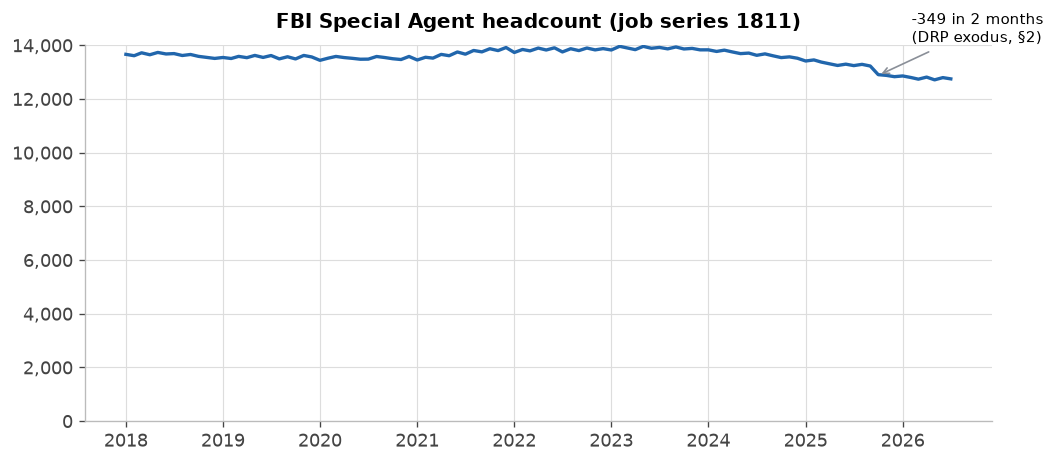

In [5]:
hc = q(f"SELECT ym, SUM(n) AS n FROM '{lib.FBI_EMP}' GROUP BY 1 ORDER BY 1")
hc["date"] = pd.to_datetime(hc.ym, format="%Y%m")
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(hc.date, hc.n, lw=2, color=C_MAIN)
ax.set_title("FBI Special Agent headcount (job series 1811)")
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}"))
date_x(ax)

drop_start = int(scalar(f"SELECT SUM(n) FROM '{lib.FBI_EMP}' WHERE ym='202509'"))
drop_end = int(scalar(f"SELECT SUM(n) FROM '{lib.FBI_EMP}' WHERE ym='202511'"))
drop_date = pd.to_datetime("202510", format="%Y%m")
ax.annotate(f"-{drop_start-drop_end:,} in 2 months\n(DRP exodus, \u00a72)", xy=(drop_date, drop_end),
            xytext=(20, 20), textcoords="offset points", fontsize=9,
            arrowprops=dict(arrowstyle="->", color=C_MUTED))
fig.tight_layout()
print(f"Sep 2025 -> Nov 2025: {drop_start:,} -> {drop_end:,} ({drop_start-drop_end:,} people) in two months.")


Under-1-year separations: 0-5/month, the whole period.


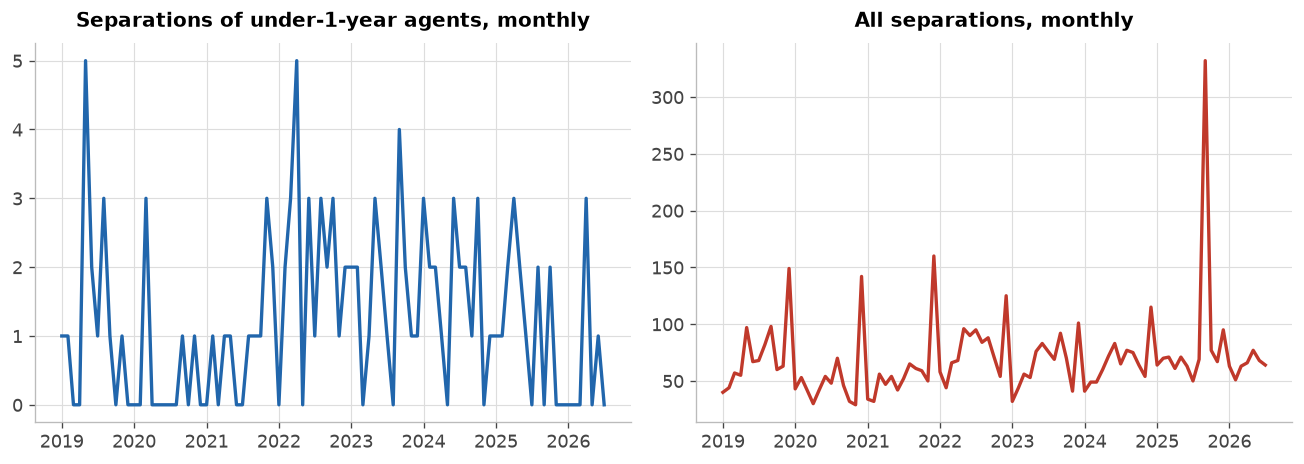

In [6]:
sep_tenure = q(f"""
    SELECT ym, SUM(CASE WHEN {dbl('length_of_service_years')} < 1 THEN n ELSE 0 END) AS under_1yr, SUM(n) AS total
    FROM '{lib.FBI_SEP}' WHERE ym >= '201901' GROUP BY 1 ORDER BY 1
""")
sep_tenure["date"] = pd.to_datetime(sep_tenure.ym, format="%Y%m")
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(sep_tenure.date, sep_tenure.under_1yr, lw=2, color=C_MAIN)
axes[0].set_title("Separations of under-1-year agents, monthly")
axes[1].plot(sep_tenure.date, sep_tenure.total, lw=2, color=C_ALT)
axes[1].set_title("All separations, monthly")
for ax in axes: date_x(ax)
fig.tight_layout()
print(f"Under-1-year separations: {sep_tenure.under_1yr.min():.0f}-{sep_tenure.under_1yr.max():.0f}/month, the whole period.")

In [7]:
drp = q(f"""
    SELECT separation_category, drp_indicator, SUM(n) AS n FROM '{lib.FBI_SEP}'
    WHERE ym = '{lib.DRP_MONTH}' GROUP BY 1,2 ORDER BY n DESC
""")
display(show(drp.rename(columns={"separation_category":"Category","drp_indicator":"DRP-flagged","n":"People"})))
total = int(drp.n.sum()); drp_yes = int(drp.loc[drp.drp_indicator=="Y","n"].sum())
los = q(f"SELECT {dbl('length_of_service_years')} AS los, SUM(n) AS n FROM '{lib.FBI_SEP}' WHERE ym='{lib.DRP_MONTH}' GROUP BY 1")
mean_tenure = (los.los*los.n).sum()/los.n.sum()
share_20plus = 100*los.loc[los.los>=20,"n"].sum()/los.n.sum()
print(f"{ym_label(lib.DRP_MONTH)}: {total} separations, {drp_yes} ({100*drp_yes/total:.0f}%) DRP-flagged, "
      f"average tenure {mean_tenure:.1f} yrs, {share_20plus:.0f}% with 20+ years in.")

Category,DRP-flagged,People
RETIREMENT - VOLUNTARY,Y,189
QUIT,Y,56
RETIREMENT - VOLUNTARY,N,51
TERMINATION (EXPIRED APPT/OTHER),N,11
RETIREMENT - OTHER,N,6
QUIT,N,6
OTHER SEPARATION,N,5
RETIREMENT - OTHER,Y,5
RETIREMENT - EARLY OUT,N,2
TRANSFER OUT - INDIVIDUAL TRANSFER,N,1


Sep 2025: 332 separations, 250 (75%) DRP-flagged, average tenure 21.8 yrs, 78% with 20+ years in.


**No rookie-attrition signal.** Under-1-year departures sit at a handful a month throughout.
September's spike was a DRP-driven exodus of ~22-year veterans, not new agents washing out -- a
real shock, not a hiring-standards story. A useful negative result: the method rules problems out,
not just in.

## 3. Is ICE the only one? A corrected, government-wide screen

Every agency, every job series (not restricted to law enforcement), using the fixed method: hires
and departures counted in the same window, departures attributed to implied hire month, no
reliance on a shrinking or growing stock.

In [8]:
def cohort_table(sep_rawlos_path, acc_path, window_start, window_end, min_hires=30):
    sep_raw = q(f"SELECT * FROM '{sep_rawlos_path}'")
    cohort = lib.implied_hire_cohort(sep_raw, window_start, window_end)
    seps = cohort.groupby(["agency_subelement_code","agency_subelement"])["n"].sum().rename("seps")
    hires_df = q(f"SELECT ym, agency_subelement, agency_subelement_code, SUM(n) AS n FROM '{acc_path}' GROUP BY 1,2,3")
    hires = (hires_df[(hires_df.ym >= window_start) & (hires_df.ym <= window_end)]
             .groupby(["agency_subelement_code","agency_subelement"])["n"].sum().rename("hires"))
    out = pd.concat([hires, seps], axis=1).fillna(0).reset_index()
    out = out[out.hires >= min_hires]
    out["pct"] = 100*out.seps/out.hires
    return out

post = cohort_table(lib.SCREEN_PERM_SEP_RAWLOS, lib.SCREEN_PERM_ACC, lib.POST_START, lib.POST_END)
prior = cohort_table(lib.SCREEN_PERM_SEP_RAWLOS_PRIORYEAR, lib.SCREEN_PERM_ACC, lib.PRIOR_START, lib.PRIOR_END)

yoy = post.merge(prior, on=["agency_subelement_code","agency_subelement"], suffixes=("_post","_prior"), how="inner")
yoy["change_pp"] = yoy.pct_post - yoy.pct_prior
print(f"{len(yoy)} agencies with 30+ permanent new hires in both the post and prior windows.")

131 agencies with 30+ permanent new hires in both the post and prior windows.


In [9]:
top_change = yoy.sort_values("change_pp", ascending=False).head(10)
show(top_change[["agency_subelement_code","agency_subelement","hires_prior","hires_post","pct_prior","pct_post","change_pp"]]
     .rename(columns={"agency_subelement_code":"Code","agency_subelement":"Agency","hires_prior":"Hires (prior yr)",
                       "hires_post":"Hires (post-Sep’25)","pct_prior":"Exit % (prior yr)","pct_post":"Exit % (post-Sep’25)",
                       "change_pp":"Change (pp)"}), pct=["Exit % (prior yr)","Exit % (post-Sep’25)"])

Code,Agency,Hires (prior yr),Hires (post-Sep’25),Exit % (prior yr),Exit % (post-Sep’25),Change (pp)
HSBB,IMMIGRATION AND CUSTOMS ENFORCEMENT,"1,188","8,223",4.3%,17.5%,13.2
TR93,INTERNAL REVENUE SERVICE,"7,792","1,208",21.0%,28.9%,7.8
HSBE,FEDERAL LAW ENFORCEMENT TRAINING CENTERS,57,84,1.8%,8.3%,6.6
IN10,NATIONAL PARK SERVICE,713,673,5.6%,9.1%,3.5
DJ15,"BUREAU OF ALCOHOL, TOBACCO, FIREARMS, AND EXPLOSIVES",105,48,1.9%,4.2%,2.3
DJ06,DRUG ENFORCEMENT ADMINISTRATION,322,441,2.2%,4.3%,2.1
NV14,OFFICE OF NAVAL RESEARCH,98,33,4.1%,6.1%,2.0
IN06,INDIAN AFFAIRS,164,106,8.5%,10.4%,1.8
DD27,MISSILE DEFENSE AGENCY,200,51,3.5%,3.9%,0.4
DD82,NATIONAL RECONNAISSANCE OFFICE,90,66,1.1%,1.5%,0.4


In [10]:
# Why sorting by the raw rate (not the change) is misleading: check the highest post-Sep'25
# rates, plus Defense Commissary Agency specifically (high level, but improving).
top_level = pd.concat([
    yoy.sort_values("pct_post", ascending=False).head(3),
    yoy[yoy.agency_subelement_code == "DD34"],
])
show(top_level[["agency_subelement_code","agency_subelement","pct_prior","pct_post","change_pp"]]
     .rename(columns={"agency_subelement_code":"Code","agency_subelement":"Agency",
                       "pct_prior":"Exit % (prior yr)","pct_post":"Exit % (post-Sep’25)","change_pp":"Change (pp)"}),
     pct=["Exit % (prior yr)","Exit % (post-Sep’25)"])

Code,Agency,Exit % (prior yr),Exit % (post-Sep’25),Change (pp)
TR93,INTERNAL REVENUE SERVICE,21.0%,28.9%,7.8
HSBC,TRANSPORTATION SECURITY ADMINISTRATION,18.1%,17.7%,-0.4
HSBB,IMMIGRATION AND CUSTOMS ENFORCEMENT,4.3%,17.5%,13.2
DD34,DEFENSE COMMISSARY AGENCY,32.7%,13.5%,-19.2


Sorting by the raw rate is misleading -- TSA's ~18% looks alarming but has always run there
(structurally high screener turnover). Defense Commissary Agency's rate actually *improved*.
**Sorted by the change instead, only two agencies combine real hiring volume with a genuinely
worsened rate: ICE (+13 points) and IRS (+8 points).** Everything else is noise or a wash.

## 4. What's going on at IRS?

Same drill-down `dhs_hiring_surge.ipynb` does for ICE: which job, and why.

In [11]:
by_series = q(f"""
    SELECT occupational_series_code,
           SUM(CASE WHEN ym BETWEEN '{lib.PRIOR_START}' AND '{lib.PRIOR_END}' THEN n ELSE 0 END) AS hires_prior,
           SUM(CASE WHEN ym >= '{lib.POST_START}' THEN n ELSE 0 END) AS hires_post
    FROM '{lib.IRS_ACC}' GROUP BY 1 ORDER BY hires_prior DESC LIMIT 8
""")
display(show(by_series.rename(columns={"occupational_series_code":"Series","hires_prior":"Hires (prior yr)","hires_post":"Hires (post-Sep’25)"})))

total_irs_hires_post = int(scalar(f"SELECT SUM(n) FROM '{lib.IRS_ACC}' WHERE ym >= '{lib.POST_START}'"))
hires_0962_post = int(by_series.loc[by_series.occupational_series_code=="0962","hires_post"].iloc[0])
print(f"0962 is {100*hires_0962_post/total_irs_hires_post:.0f}% of all IRS hiring since Sep’25 "
      f"({hires_0962_post:,} of {total_irs_hires_post:,}).")

Series,Hires (prior yr),Hires (post-Sep’25)
0962,"2,435","1,108"
0512,"1,402",2
0592,"1,254",0
0303,866,0
2210,404,1
1169,201,0
1811,167,82
1102,89,0


0962 is 92% of all IRS hiring since Sep’25 (1,108 of 1,208).


IRS froze hiring everywhere -- Revenue Agents, Tax Examiners, clerical, IT -- **except
Contact Representatives** (call-center/taxpayer-service reps, series 0962), 92% of all IRS hiring
since September. The 28.9% government-wide number is almost entirely a Contact Representative
story.

In [12]:
sep_raw = q(f"SELECT * FROM '{lib.IRS_SEP}' WHERE occupational_series_code='0962'")
cohort = lib.implied_hire_cohort(sep_raw, lib.POST_START, lib.POST_END)
hires_0962 = int(scalar(f"SELECT SUM(n) FROM '{lib.IRS_ACC}' WHERE occupational_series_code='0962' AND ym >= '{lib.POST_START}'"))
print(f"0962 hires since Sep'25: {hires_0962:,}")
print(f"0962 cohort departures so far: {int(cohort.n.sum()):,}  ({100*cohort.n.sum()/hires_0962:.1f}%)")

why = cohort.groupby(["separation_category","drp_indicator"])["n"].sum().reset_index().sort_values("n", ascending=False)
display(show(why.rename(columns={"separation_category":"Reason","drp_indicator":"DRP-flagged","n":"People"})))

0962 hires since Sep'25: 1,108
0962 cohort departures so far: 333  (30.1%)


Reason,DRP-flagged,People
QUIT,N,293
TERMINATION (EXPIRED APPT/OTHER),N,31
OTHER SEPARATION,N,6
TRANSFER OUT - INDIVIDUAL TRANSFER,N,3


30% gone, 88% a plain voluntary quit (not DRP, not a firing). Worth checking history: is the
rate itself unusual, and is it part of a longer trend?

**Is any of this actually unusual for this job?** Contact Representative is a call-center role
with a reputation for high turnover. Check the full 2019-2026 history.

In [13]:
acc_hist = q(f"SELECT ym, n FROM '{lib.IRS_0962_ACC_HIST}'")
sep_hist = q(f"SELECT ym, length_of_service_years, separation_category, n FROM '{lib.IRS_0962_SEP_HIST}'")

windows = [("2019-20","201909","202007"), ("2020-21","202009","202107"),
           ("2021-22","202109","202207"), ("2022-23","202209","202307"),
           ("2023-24","202309","202407"), ("2024-25","202409","202507"),
           ("2025-26","202509","202607")]
rows = []
for label, s, e in windows:
    hires = acc_hist[(acc_hist.ym>=s)&(acc_hist.ym<=e)].n.sum()
    if hires == 0: continue
    c = lib.implied_hire_cohort(sep_hist, s, e)
    quits = c[c.separation_category=="QUIT"].n.sum()
    c2mo = c[(c.los*12).round() <= 2]
    rows.append({"Hiring window": label, "Hires": hires, "Left by window end": int(c.n.sum()),
                 "Exit %": round(100*c.n.sum()/hires,1), "Quit %": round(100*quits/hires,1),
                 "Left within 0-2mo": int(c2mo.n.sum()), "Quick-quit %": round(100*c2mo.n.sum()/hires,1)})
hist_df = pd.DataFrame(rows)
display(show(hist_df, pct=["Exit %","Quit %","Quick-quit %"]))

Hiring window,Hires,Left by window end,Exit %,Quit %,Left within 0-2mo,Quick-quit %
2019-20,"3,018",511,16.9%,14.1%,275,9.1%
2020-21,"4,032",880,21.8%,19.6%,326,8.1%
2021-22,"5,623","1,698",30.2%,27.7%,786,14.0%
2022-23,"7,218","1,560",21.6%,19.6%,813,11.3%
2023-24,"5,240",637,12.2%,10.7%,335,6.4%
2024-25,"2,435",465,19.1%,16.6%,207,8.5%
2025-26,"1,108",333,30.1%,26.4%,157,14.2%


**Does `implied_hire_cohort()` miss anyone?** The correction assumes tenure-at-separation
reflects time in *this* job. But §1 already found ~8% of FBI new hires carry prior federal
credit -- for them, tenure at separation reflects their *whole* federal career, not just this
role. A lateral 0962 hire who quit fast would get an implied hire date years in the past and
silently drop out of the cohort count. How big a blind spot is this for Contact Reps
specifically?

In [14]:
acc_los = q(f"SELECT ym, {dbl('length_of_service_years')} AS los, n FROM '{lib.IRS_0962_ACC_LOS}'")
total = acc_los.n.sum()
zero = acc_los.loc[acc_los.los==0, "n"].sum()
one_plus = acc_los.loc[acc_los.los>=1, "n"].sum()
print(f"All 0962 hires, 2019-2026: {int(total):,} total, {100*zero/total:.1f}% exactly 0 years, "
      f"{100*one_plus/total:.1f}% with 1+ years of prior credit.")

recent_acc = acc_los[acc_los.ym >= lib.POST_START]
recent_total = recent_acc.n.sum()
recent_one_plus = recent_acc.loc[recent_acc.los>=1, "n"].sum()
print(f"Post-Sep'25 hires specifically: {int(recent_total):,} total, "
      f"{int(recent_one_plus)} ({100*recent_one_plus/recent_total:.1f}%) with 1+ years of prior credit.")

worst_case_pct = 100*(157 + recent_one_plus)/1108
print(f"Worst-case upper bound on the 14.2% quick-quit rate (if EVERY lateral hire also quit "
      f"fast and was missed): {worst_case_pct:.1f}%.")

All 0962 hires, 2019-2026: 32,270 total, 98.3% exactly 0 years, 1.3% with 1+ years of prior credit.
Post-Sep'25 hires specifically: 1,108 total, 52 (4.7%) with 1+ years of prior credit.
Worst-case upper bound on the 14.2% quick-quit rate (if EVERY lateral hire also quit fast and was missed): 18.9%.


**Small blind spot, unlike FBI.** Only 1.3% of 0962 hires overall (4.7% in the post-Sep'25
window) carry prior federal credit -- Contact Representative is a genuinely entry-level role, not
one that draws lateral transfers the way FBI Special Agent does. Even the unrealistic worst case
(every one of those lateral hires also quit fast and got missed) only pushes 14.2% up to ~18.9% --
real, but not enough to change the conclusion. This is exactly the kind of check worth doing before
trusting a cohort number, and here it comes back clean.

**The headline: IRS Contact Representatives -- the phone-line taxpayer-service reps at
IRS's main call center -- are leaving faster, in a shrinking workforce, and IRS isn't replacing
them.** None of those three is a record alone. All three, at once, right now:

- **Faster:** the share of new hires gone within 2 months climbed for three straight years --
  6.4% (2023-24) -> 8.5% (2024-25) -> 14.2% (2025-26) -- back to the 2021-22 peak (14.0%).
- **Shrinking:** headcount peaked at 25,221 (Dec 2024), down 28% (7,076 people) to 18,145 (Jul
  2026).
- **Not replaced:** net headcount change negative in 10 of the last 11 months.

Headcount peaked at 25,221 (Dec 2024), now 18,145 (Jul 2026) -- down 28.1%.
10 of the last 11 months were net headcount losses for 0962.


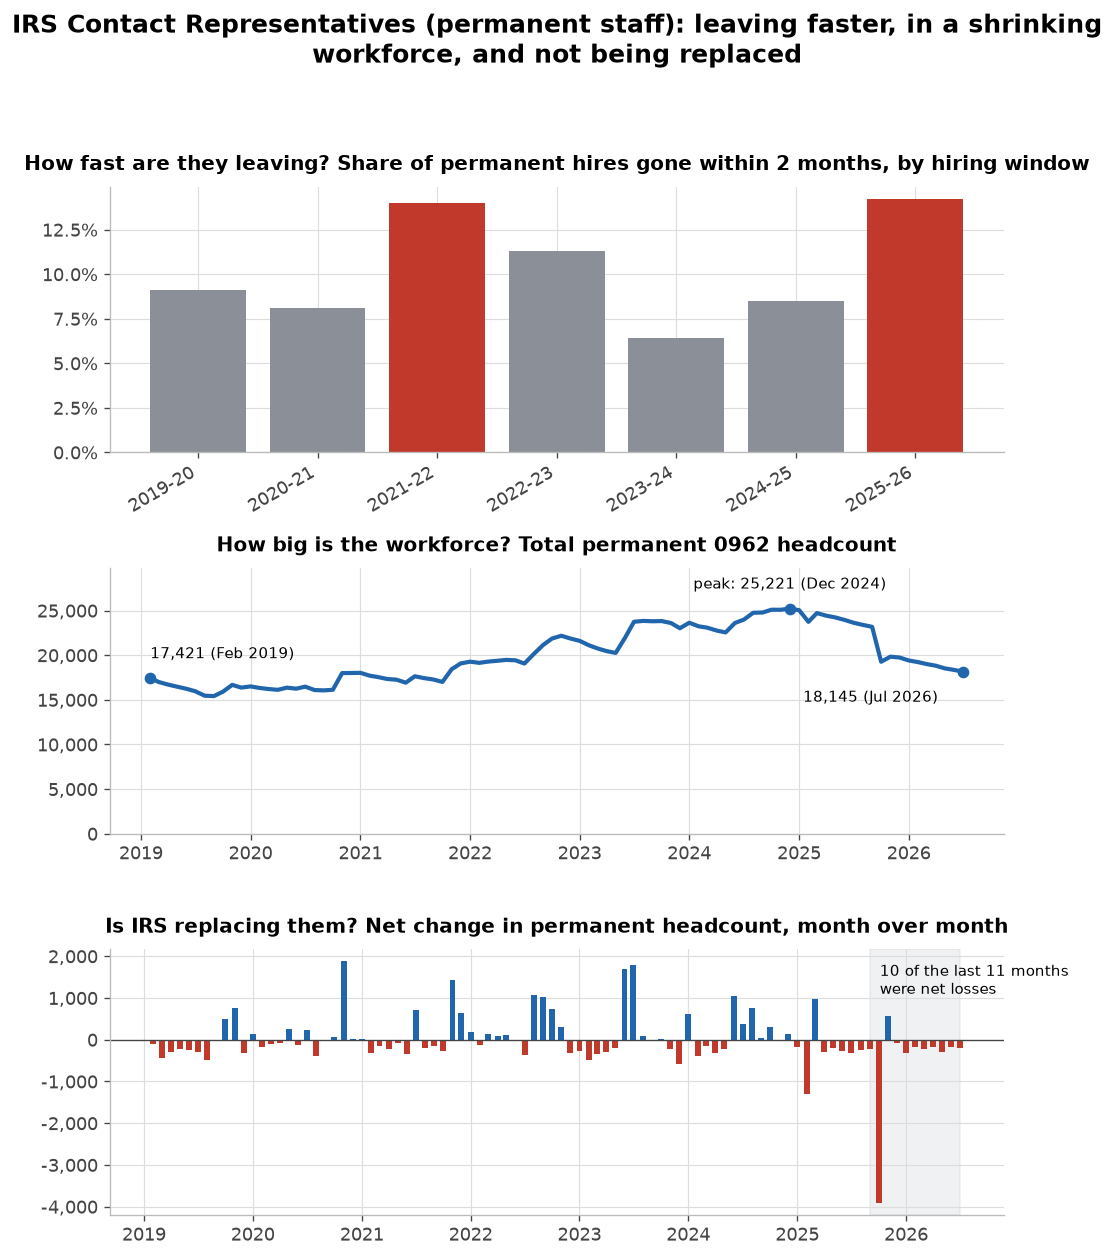

In [15]:
# The hero chart: three panels, one image, the whole "not being replaced" story in one
# place. Top -- quit speed by hiring-window-year, full history (not a new record, but a
# real recent climb). Middle -- total headcount over time (the role itself, shrinking).
# Bottom -- net change in headcount, month over month (the mechanism: is IRS actually
# replacing departures, or not).
emp_all = q(f"SELECT ym, {dbl('length_of_service_years')} AS los, n FROM '{lib.IRS_0962_EMP_HIST}'")
monthly = emp_all.groupby("ym")["n"].sum().reset_index()
monthly["date"] = pd.to_datetime(monthly.ym, format="%Y%m")
monthly["net_change"] = monthly.n.diff()
monthly = monthly[monthly.ym >= "201902"]

fig, (ax_speed, ax_level, ax_net) = plt.subplots(3, 1, figsize=(9, 10.5))

x = range(len(hist_df))
colors_speed = [C_ALT if w.startswith(("2021","2025")) else C_MUTED for w in hist_df["Hiring window"]]
ax_speed.bar(x, hist_df["Quick-quit %"], color=colors_speed)
ax_speed.set_xticks(list(x)); ax_speed.set_xticklabels(hist_df["Hiring window"], rotation=30, ha="right")
ax_speed.yaxis.set_major_formatter(mtick.PercentFormatter())
ax_speed.set_title("How fast are they leaving? Share of permanent hires gone within 2 months, by hiring window")

ax_level.plot(monthly.date, monthly.n, lw=2.5, color=C_MAIN)
ax_level.set_ylim(0, monthly.n.max() * 1.18)
ax_level.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax_level.set_title("How big is the workforce? Total permanent 0962 headcount")
date_x(ax_level)
first = monthly.iloc[0]
peak = monthly.loc[monthly.n.idxmax()]
latest = monthly.iloc[-1]
ax_level.plot([first.date, peak.date, latest.date], [first.n, peak.n, latest.n], "o", color=C_MAIN, ms=6, zorder=5)
ax_level.annotate(f"{first.n:,.0f} ({ym_label(first.ym)})", xy=(first.date, first.n), xytext=(0, 12),
                   textcoords="offset points", ha="left", fontsize=9)
ax_level.annotate(f"peak: {peak.n:,.0f} ({ym_label(peak.ym)})", xy=(peak.date, peak.n), xytext=(0, 12),
                   textcoords="offset points", ha="center", fontsize=9)
ax_level.annotate(f"{latest.n:,.0f} ({ym_label(latest.ym)})", xy=(latest.date, latest.n), xytext=(-15, -18),
                   textcoords="offset points", ha="right", fontsize=9)

colors_net = [C_ALT if v < 0 else C_MAIN for v in monthly.net_change]
ax_net.bar(monthly.date, monthly.net_change, width=20, color=colors_net)
ax_net.axhline(0, color="#444", lw=0.8)
ax_net.set(title="Is IRS replacing them? Net change in permanent headcount, month over month")
ax_net.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}"))
date_x(ax_net)
months_negative = int((monthly.tail(11).net_change < 0).sum())
ax_net.axvspan(monthly.date.iloc[-11], monthly.date.iloc[-1], color=C_MUTED, alpha=0.12, zorder=0)
ax_net.text(monthly.date.iloc[-11], ax_net.get_ylim()[1] * 0.85, f"  {months_negative} of the last 11 months\n  were net losses",
            fontsize=9, va="top")

fig.suptitle("IRS Contact Representatives (permanent staff): leaving faster, in a shrinking\nworkforce, and not being replaced",
             fontsize=15, fontweight="bold", y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig("figures/irs_0962_summary.png")
print(f"Headcount peaked at {peak.n:,.0f} ({ym_label(peak.ym)}), now {latest.n:,.0f} ({ym_label(latest.ym)}) "
      f"-- down {100*(peak.n-latest.n)/peak.n:.1f}%.")
print(f"{months_negative} of the last 11 months were net headcount losses for 0962.")

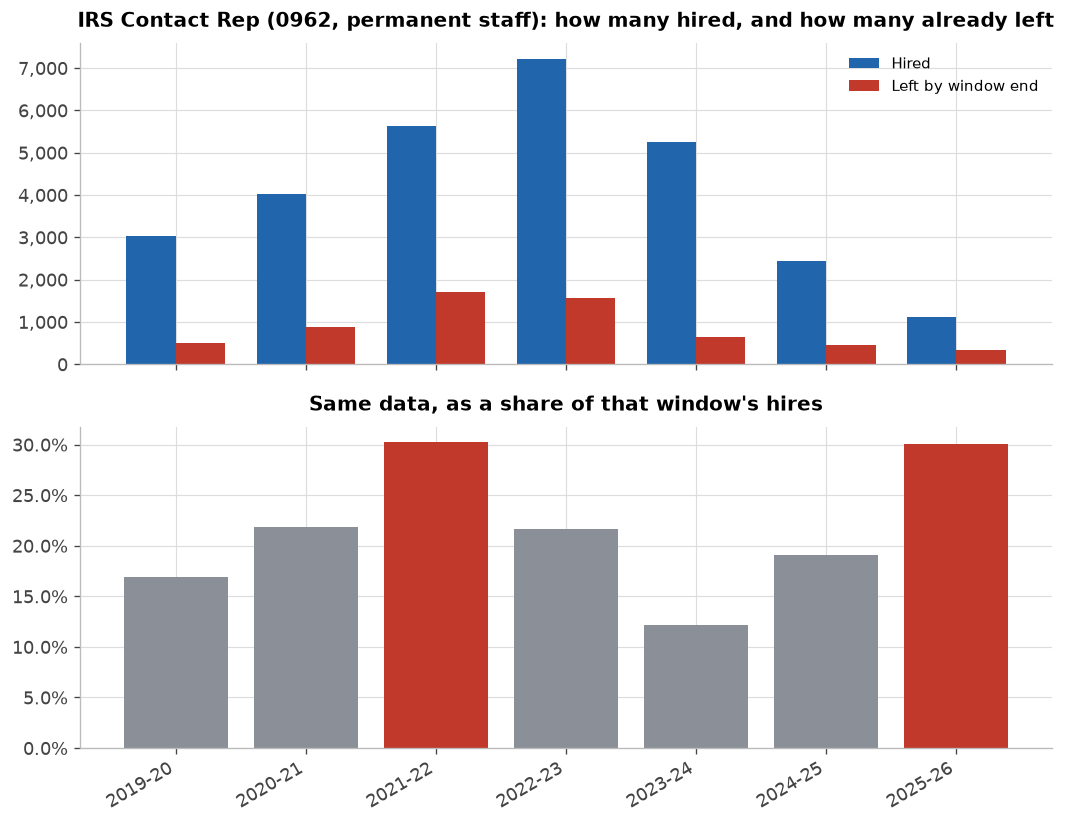

In [16]:
# One image, two panels: raw counts (is this actually a big cohort?) stacked on the
# rate (is the cohort's own attrition unusual?) -- neither panel alone tells the story.
fig, (ax_n, ax_pct) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
x = range(len(hist_df))
width = 0.38
ax_n.bar([i - width/2 for i in x], hist_df["Hires"], width=width, color=C_MAIN, label="Hired")
ax_n.bar([i + width/2 for i in x], hist_df["Left by window end"], width=width, color=C_ALT, label="Left by window end")
ax_n.set_title("IRS Contact Rep (0962, permanent staff): how many hired, and how many already left")
ax_n.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax_n.legend(fontsize=9)

colors = [C_ALT if w.startswith("2025") or w.startswith("2021") else C_MUTED for w in hist_df["Hiring window"]]
ax_pct.bar(x, hist_df["Exit %"], color=colors)
ax_pct.set_title("Same data, as a share of that window's hires")
ax_pct.yaxis.set_major_formatter(mtick.PercentFormatter())
ax_pct.set_xticks(list(x)); ax_pct.set_xticklabels(hist_df["Hiring window"], rotation=30, ha="right")

fig.tight_layout(); fig.savefig("figures/irs_0962_story.png")

In [17]:
# Composition check: how much of the workforce is even still a recent hire? Reuses the
# same emp_all pull from the hero chart above (length_of_service_years per snapshot).
comp = emp_all.groupby("ym").apply(lambda g: pd.Series({
    "total": g.n.sum(), "under_1yr": g.loc[g.los < 1, "n"].sum()
}), include_groups=False).reset_index()
comp["pct_under1"] = 100 * comp.under_1yr / comp.total
peak_share = comp.loc[comp.pct_under1.idxmax()]
latest_share = comp.iloc[-1]
print(f"Under-1-year share of total 0962 headcount: peaked at {peak_share.pct_under1:.1f}% "
      f"({ym_label(peak_share.ym)}), now {latest_share.pct_under1:.1f}% ({ym_label(latest_share.ym)}).")

Under-1-year share of total 0962 headcount: peaked at 31.9% (Oct 2022), now 3.1% (Jul 2026).


One more angle on the same shrinkage: under-1-year employees were **31.9%** of the whole
0962 workforce at the 2022 peak -- nearly a third brand new. Today: **3.1%**, the lowest in the
series -- mostly-fresh to almost entirely veteran, well before this window started.

## 5. Are people leaving voluntarily? A second mechanism, not the same one

Everything above about "leaving faster" is about the recent-hire cohort specifically. It says
nothing about whether the *whole* workforce's departures -- including longer-tenured people --
are organic quitting or something else, like the same DRP buyout wave that hit FBI. That matters:
if the "shrinking, not replaced" story is really one discrete buyout event, it's a different
finding than accelerating organic attrition.

In [18]:
sep_all = q(f"SELECT * FROM '{lib.IRS_0962_SEP_ALLTENURE}'")

def breakdown(df, label):
    total = df.n.sum()
    quit_nondrp = df[(df.separation_category=="QUIT") & (df.drp_indicator=="N")].n.sum()
    drp = df[df.drp_indicator=="Y"].n.sum()
    term = df[df.separation_category.str.startswith("TERMINATION")].n.sum()
    print(f"{label}: {int(total):,} total separations -- "
          f"{100*quit_nondrp/total:.0f}% plain voluntary quit, {100*drp/total:.0f}% DRP-flagged, "
          f"{100*term/total:.0f}% involuntary termination.")

breakdown(sep_all[(sep_all.ym >= lib.POST_START) & (sep_all.ym <= lib.POST_END)], "Sep’25-Jul’26 (all tenures)")
breakdown(sep_all[(sep_all.ym >= lib.PRIOR_START) & (sep_all.ym <= lib.PRIOR_END)], "Sep’24-Jul’25 (all tenures)")

Sep’25-Jul’26 (all tenures): 6,241 total separations -- 18% plain voluntary quit, 73% DRP-flagged, 2% involuntary termination.
Sep’24-Jul’25 (all tenures): 2,827 total separations -- 65% plain voluntary quit, 0% DRP-flagged, 3% involuntary termination.


Sep 2025 alone: 4,614 separations, 4,467 (97%) DRP-flagged.
Every other month, 2024-26: 145-442/month, 102 DRP-flagged total.


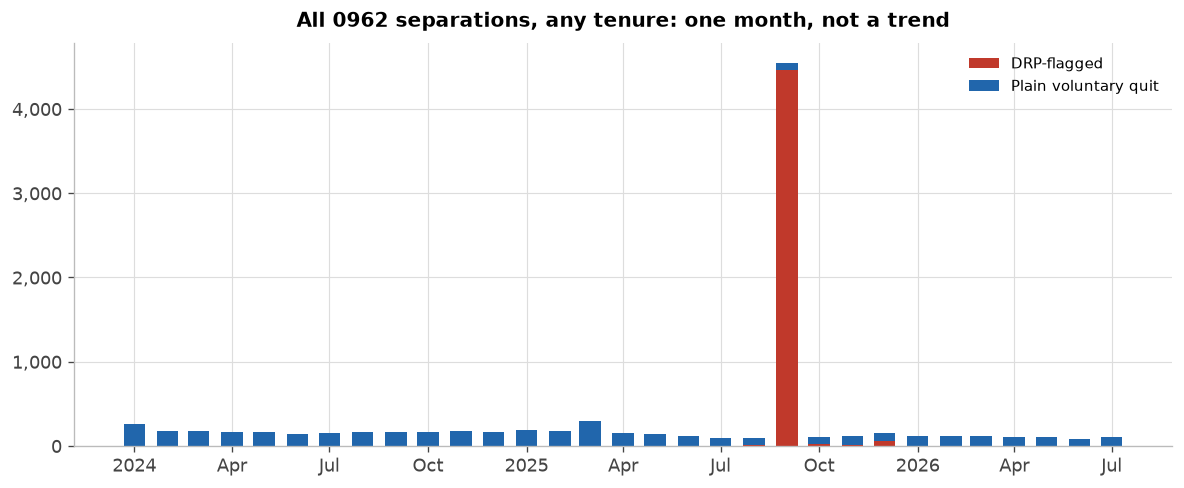

In [19]:
monthly_all = sep_all.groupby("ym").apply(lambda g: pd.Series({
    "total": g.n.sum(), "drp": g.loc[g.drp_indicator=="Y","n"].sum(),
    "quit_nondrp": g.loc[(g.separation_category=="QUIT") & (g.drp_indicator=="N"),"n"].sum(),
}), include_groups=False).reset_index()
monthly_all["date"] = pd.to_datetime(monthly_all.ym, format="%Y%m")
monthly_all = monthly_all[monthly_all.ym >= "202401"]

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.bar(monthly_all.date, monthly_all.drp, width=20, color=C_ALT, label="DRP-flagged")
ax.bar(monthly_all.date, monthly_all.quit_nondrp, bottom=monthly_all.drp, width=20, color=C_MAIN, label="Plain voluntary quit")
ax.set_title("All 0962 separations, any tenure: one month, not a trend")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}"))
date_x(ax)
ax.legend(fontsize=9)
fig.tight_layout(); fig.savefig("figures/irs_0962_drp_isolation.png")

sep25_total = int(monthly_all.loc[monthly_all.ym=="202509","total"].iloc[0])
sep25_drp = int(monthly_all.loc[monthly_all.ym=="202509","drp"].iloc[0])
print(f"Sep 2025 alone: {sep25_total:,} separations, {sep25_drp:,} ({100*sep25_drp/sep25_total:.0f}%) DRP-flagged.")
other_months = monthly_all[monthly_all.ym != "202509"]
print(f"Every other month, 2024-26: {other_months.total.min():.0f}-{other_months.total.max():.0f}/month, "
      f"{other_months.drp.sum():.0f} DRP-flagged total.")

**One month, not a trend.** September 2025 alone had 4,614 separations, 97% DRP-flagged -- a
single buyout event. Every other month, before and after, runs a steady 145-442, with almost no
DRP flags. Compare the prior year, which had zero DRP and 65% plain voluntary quit: post-Sep'25,
plain voluntary quit drops to 18% of all separations, not because people are quitting less, but
because the DRP wave swamps the count.

In [20]:
# Does the DRP wave contaminate the "quick-quit" cohort stat from §4? It shouldn't --
# implied_hire_cohort() attributes departures to hire vintage, and anyone leaving in Sep'25
# with any positive tenure was necessarily hired before the tracked window started.
sep25_cohort_check = lib.implied_hire_cohort(sep_hist, lib.POST_START, lib.POST_END)
sep25_in_cohort = sep25_cohort_check[sep25_cohort_check.ym == "202509"]
sep25_total_in_file = sep_hist[sep_hist.ym == "202509"].n.sum()
print(f"Of {int(sep25_total_in_file):,} Sep'25 departures in the tenure-filtered file, "
      f"{int(sep25_in_cohort.n.sum())} were (incorrectly) attributed to the Sep'25-hire cohort.")

Of 2,184 Sep'25 departures in the tenure-filtered file, 0 were (incorrectly) attributed to the Sep'25-hire cohort.


**Confirmed clean.** Zero contamination. The "leaving faster" cohort stat (§4) and this
DRP wave are two genuinely separate mechanisms: one discrete buyout event pulling in longer-tenured
staff, and a smaller but real, accelerating quit problem specifically among people hired since
September -- not one finding double-counted as two.

## Where this leaves things

- **FBI**: no signal. The 2025 shock was senior agents exiting via DRP, not new hires washing out.
- **ICE**: confirmed independently (§3) from `dhs_hiring_surge.ipynb`'s cohort finding.
- **IRS**: a real, comparably-sized finding, concentrated in Contact Representatives -- ~30% hired
  since September already quit, mostly voluntarily, within months. Not a record on its own, but
  paired with historically low hiring for the first time.
- **Everyone else**: nothing else combines real hiring volume with a genuinely worsened rate.
- **The method's limit**: this rules agencies in or out cheaply. It's an approximation from
  tenure-at-departure, not true person-level tracking -- there are no person IDs in this data.